Le pricing des billets d’avion est un enjeu important pour les compagnies aériennes, 
car les prix varient selon de nombreux facteurs (date, demande, destination,etc). 
Le problème consiste à comprendre ces variations et à prédire le prix des billets. 
Ce projet cherche donc à identifier les facteurs influents et à construire un modèle capable d’estimer les prix.

1-Préparation et prétraitement des données 

In [251]:
import pandas as pd
import numpy as np
import re

In [252]:
data_Train = pd.read_excel("Data_Train.xlsx")
data_Test = pd.read_excel("Test_set.xlsx")
data_prediction_test = pd.read_excel("Sample_submission.xlsx")
data_Test = pd.concat([data_Test, data_prediction_test], axis=1)
data = pd.concat([data_Train, data_Test], axis=0)

In [253]:
data.head(15)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
5,SpiceJet,24/06/2019,Kolkata,Banglore,CCU → BLR,09:00,11:25,2h 25m,non-stop,No info,3873
6,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,11087
7,Jet Airways,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:00,05:05 02 Mar,21h 5m,1 stop,No info,22270
8,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:55,10:25 13 Mar,25h 30m,1 stop,In-flight meal not included,11087
9,Multiple carriers,27/05/2019,Delhi,Cochin,DEL → BOM → COK,11:25,19:15,7h 50m,1 stop,No info,8625


In [254]:
# infos du dataset d'entrainement 
data.info()

<class 'pandas.DataFrame'>
Index: 13354 entries, 0 to 2670
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          13354 non-null  str  
 1   Date_of_Journey  13354 non-null  str  
 2   Source           13354 non-null  str  
 3   Destination      13354 non-null  str  
 4   Route            13353 non-null  str  
 5   Dep_Time         13354 non-null  str  
 6   Arrival_Time     13354 non-null  str  
 7   Duration         13354 non-null  str  
 8   Total_Stops      13353 non-null  str  
 9   Additional_Info  13354 non-null  str  
 10  Price            13354 non-null  int64
dtypes: int64(1), str(10)
memory usage: 1.2 MB


In [255]:
# descriprion ses données d'entrainnement
data.describe()

,Price
count,13354.000000
mean,11301.720009
std,6452.843082
min,1759.000000
25%,6135.250000
50%,10262.000000
75%,14781.000000
max,79512.000000


In [256]:
#rechercheons les valeures nulles,
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [257]:
data[data.isnull().any(axis=1)]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [258]:
#drop the nullvalues
data.dropna(inplace=True)

In [259]:
data.dtypes

Airline              str
Date_of_Journey      str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
dtype: object

In [260]:
def change_into_datetime(col):
    data[col]=pd.to_datetime(data[col])

In [261]:
for i in ['Date_of_Journey','Dep_Time', 'Arrival_Time']:
    change_into_datetime(i)

C:\Users\jorda\AppData\Local\Temp\ipykernel_41036\1802885727.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data[col]=pd.to_datetime(data[col])
C:\Users\jorda\AppData\Local\Temp\ipykernel_41036\1802885727.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[col]=pd.to_datetime(data[col])
C:\Users\jorda\AppData\Local\Temp\ipykernel_41036\1802885727.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[col]=pd.to_datetime(data[col])


In [262]:
data.dtypes

Airline                       str
Date_of_Journey    datetime64[us]
Source                        str
Destination                   str
Route                         str
Dep_Time           datetime64[us]
Arrival_Time       datetime64[us]
Duration                      str
Total_Stops                   str
Additional_Info               str
Price                       int64
dtype: object

In [263]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-03-24 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-03-24 05:50:00,2026-03-24 13:15:00,7h 25m,2 stops,No info,7662
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-03-24 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2026-03-24 18:05:00,2026-03-24 23:30:00,5h 25m,1 stop,No info,6218
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2026-03-24 16:50:00,2026-03-24 21:35:00,4h 45m,1 stop,No info,13302


In [264]:
data["mois_depart"] = data["Date_of_Journey"].dt.month
data["jour_depart"] = data["Date_of_Journey"].dt.day

In [265]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-03-24 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,3,24
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-03-24 05:50:00,2026-03-24 13:15:00,7h 25m,2 stops,No info,7662,5,1
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-03-24 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,6,9
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2026-03-24 18:05:00,2026-03-24 23:30:00,5h 25m,1 stop,No info,6218,5,12
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2026-03-24 16:50:00,2026-03-24 21:35:00,4h 45m,1 stop,No info,13302,3,1


In [266]:
data["Dep_Time"] = data["Dep_Time"].dt.strftime("%H:%M")
data["Arrival_Time"] = data["Arrival_Time"].dt.strftime("%H:%M")

In [267]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897,3,24
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,5,1
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2 stops,No info,13882,6,9
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,5,12
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,3,1


In [268]:
def convertion_duree(x):
    x = str(x)
    h = 0
    m = 0

    if "h" in x:
        h = int(x.split("h")[0])

    if "m" in x:
        if "h" in x:
            m = int(x.split("h")[1].replace("m", "").strip())
        else:
            m = int(x.replace("m", ""))

    return h*60 + m

data["duree_min"] = data["Duration"].apply(convertion_duree)

In [269]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897,3,24,170
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,5,1,445
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2 stops,No info,13882,6,9,1140
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,5,12,325
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,3,1,285


In [270]:
data["Airline"].value_counts()

Airline
Jet Airways                          4746
IndiGo                               2564
Air India                            2191
Multiple carriers                    1543
SpiceJet                             1026
Vistara                               608
Air Asia                              405
GoAir                                 240
Multiple carriers Premium economy      16
Jet Airways Business                    8
Vistara Premium economy                 5
Trujet                                  1
Name: count, dtype: int64

In [271]:
data["Route"].value_counts()

Route
DEL → BOM → COK                3000
BLR → DEL                      1941
CCU → BOM → BLR                1232
CCU → BLR                       896
BOM → HYD                       785
                               ... 
BOM → VNS → DEL → HYD             1
BLR → HBX → BOM → NAG → DEL       1
BOM → BBI → HYD                   1
BOM → VGA → TIR → HYD             1
BOM → IXC → DEL → HYD             1
Name: count, Length: 132, dtype: int64

In [272]:
data.drop("Route", axis=1, inplace=True)

In [273]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min
0,IndiGo,2019-03-24,Banglore,New Delhi,22:20,01:10,2h 50m,non-stop,No info,3897,3,24,170
1,Air India,2019-05-01,Kolkata,Banglore,05:50,13:15,7h 25m,2 stops,No info,7662,5,1,445
2,Jet Airways,2019-06-09,Delhi,Cochin,09:25,04:25,19h,2 stops,No info,13882,6,9,1140
3,IndiGo,2019-05-12,Kolkata,Banglore,18:05,23:30,5h 25m,1 stop,No info,6218,5,12,325
4,IndiGo,2019-03-01,Banglore,New Delhi,16:50,21:35,4h 45m,1 stop,No info,13302,3,1,285


In [274]:
data.info()

<class 'pandas.DataFrame'>
Index: 13353 entries, 0 to 2670
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          13353 non-null  str           
 1   Date_of_Journey  13353 non-null  datetime64[us]
 2   Source           13353 non-null  str           
 3   Destination      13353 non-null  str           
 4   Dep_Time         13353 non-null  str           
 5   Arrival_Time     13353 non-null  str           
 6   Duration         13353 non-null  str           
 7   Total_Stops      13353 non-null  str           
 8   Additional_Info  13353 non-null  str           
 9   Price            13353 non-null  int64         
 10  mois_depart      13353 non-null  int32         
 11  jour_depart      13353 non-null  int32         
 12  duree_min        13353 non-null  int64         
dtypes: datetime64[us](1), int32(2), int64(2), str(8)
memory usage: 1.3 MB


In [275]:
data["dep_hour"] = data["Dep_Time"].str.split(":").str[0].astype(int)
data["arr_hour"] = data["Arrival_Time"].str.split(":").str[0].astype(int)

In [276]:
def periode_jour(h):
    if h < 6:
        return "nuit"
    elif h < 12:
        return "matin"
    elif h < 18:
        return "apres_midi"
    else:
        return "soir"

data["periode_depart"] = data["dep_hour"].apply(periode_jour)

In [277]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min,dep_hour,arr_hour,periode_depart
0,IndiGo,2019-03-24,Banglore,New Delhi,22:20,01:10,2h 50m,non-stop,No info,3897,3,24,170,22,1,soir
1,Air India,2019-05-01,Kolkata,Banglore,05:50,13:15,7h 25m,2 stops,No info,7662,5,1,445,5,13,nuit
2,Jet Airways,2019-06-09,Delhi,Cochin,09:25,04:25,19h,2 stops,No info,13882,6,9,1140,9,4,matin
3,IndiGo,2019-05-12,Kolkata,Banglore,18:05,23:30,5h 25m,1 stop,No info,6218,5,12,325,18,23,soir
4,IndiGo,2019-03-01,Banglore,New Delhi,16:50,21:35,4h 45m,1 stop,No info,13302,3,1,285,16,21,apres_midi


In [278]:
data["Additional_Info"].value_counts()

Additional_Info
No info                         10492
In-flight meal not included      2426
No check-in baggage included      396
1 Long layover                     20
Change airports                     8
Business class                      5
No Info                             3
1 Short layover                     1
Red-eye flight                      1
2 Long layover                      1
Name: count, dtype: int64

In [279]:
data["Additional_Info"] = (
    data["Additional_Info"]
    .str.lower()
    .str.strip()
)

In [280]:
data["Additional_Info"].value_counts()

Additional_Info
no info                         10495
in-flight meal not included      2426
no check-in baggage included      396
1 long layover                     20
change airports                     8
business class                      5
1 short layover                     1
red-eye flight                      1
2 long layover                      1
Name: count, dtype: int64

In [281]:
data["Source"] = (
    data_Train["Source"]
    .str.lower()
    .str.strip()
)

In [282]:
data["Destination"] = (
    data["Destination"]
    .str.lower()
    .str.strip()
)

In [283]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min,dep_hour,arr_hour,periode_depart
0,IndiGo,2019-03-24,banglore,new delhi,22:20,01:10,2h 50m,non-stop,no info,3897,3,24,170,22,1,soir
1,Air India,2019-05-01,kolkata,banglore,05:50,13:15,7h 25m,2 stops,no info,7662,5,1,445,5,13,nuit
2,Jet Airways,2019-06-09,delhi,cochin,09:25,04:25,19h,2 stops,no info,13882,6,9,1140,9,4,matin
3,IndiGo,2019-05-12,kolkata,banglore,18:05,23:30,5h 25m,1 stop,no info,6218,5,12,325,18,23,soir
4,IndiGo,2019-03-01,banglore,new delhi,16:50,21:35,4h 45m,1 stop,no info,13302,3,1,285,16,21,apres_midi


In [284]:
data["Total_Stops"].value_counts()

Total_Stops
1 stop      7056
non-stop    4340
2 stops     1899
3 stops       56
4 stops        2
Name: count, dtype: int64

In [285]:
data["Total_Stops"] = data["Total_Stops"].replace({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
})

In [286]:
data.info()

<class 'pandas.DataFrame'>
Index: 13353 entries, 0 to 2670
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          13353 non-null  str           
 1   Date_of_Journey  13353 non-null  datetime64[us]
 2   Source           13353 non-null  str           
 3   Destination      13353 non-null  str           
 4   Dep_Time         13353 non-null  str           
 5   Arrival_Time     13353 non-null  str           
 6   Duration         13353 non-null  str           
 7   Total_Stops      13353 non-null  object        
 8   Additional_Info  13353 non-null  str           
 9   Price            13353 non-null  int64         
 10  mois_depart      13353 non-null  int32         
 11  jour_depart      13353 non-null  int32         
 12  duree_min        13353 non-null  int64         
 13  dep_hour         13353 non-null  int64         
 14  arr_hour         13353 non-null  int64         
 15  pe

In [287]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min,dep_hour,arr_hour,periode_depart
0,IndiGo,2019-03-24,banglore,new delhi,22:20,01:10,2h 50m,0,no info,3897,3,24,170,22,1,soir
1,Air India,2019-05-01,kolkata,banglore,05:50,13:15,7h 25m,2,no info,7662,5,1,445,5,13,nuit
2,Jet Airways,2019-06-09,delhi,cochin,09:25,04:25,19h,2,no info,13882,6,9,1140,9,4,matin
3,IndiGo,2019-05-12,kolkata,banglore,18:05,23:30,5h 25m,1,no info,6218,5,12,325,18,23,soir
4,IndiGo,2019-03-01,banglore,new delhi,16:50,21:35,4h 45m,1,no info,13302,3,1,285,16,21,apres_midi


In [288]:
data["Total_Stops"] = data["Total_Stops"].astype(int)

2- Visualisation des données:
cette approche est utilisé pour:
-comprendre les rélations entre les données et déterminer les données importantes 
-mener des analyse données
-comprendre la répartition des données 

In [289]:
#importation des bibiothèques utiles
import seaborn as sns 
import matplotlib.pyplot as plt

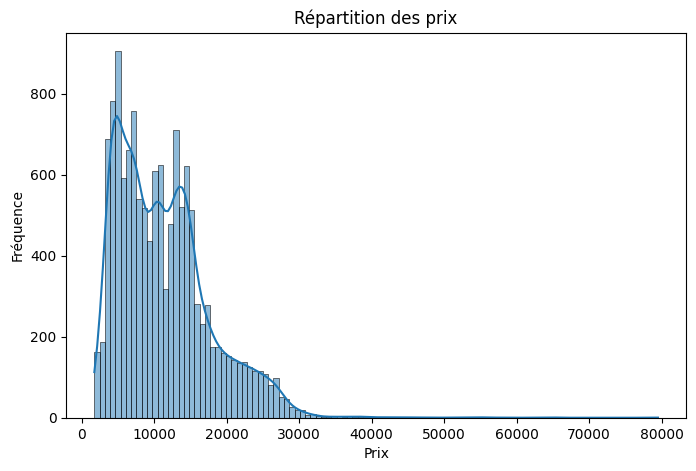

In [290]:
#Visualisation de la répartition des données: ce visuel permet de voir la répartition des données( symetrique/asymétrique) 
#---ce visuel permet également de déterminé les valeurs abérante qui pourrais influencer les corrélations

plt.figure(figsize=(8,5))
sns.histplot(data['Price'], kde=True)  # kde = courbe de densité
plt.title('Répartition des prix')
plt.xlabel('Prix')
plt.ylabel('Fréquence')
plt.show()

Interprétation: ce visuel permet de voir que les données sont asymétrique, ceci nous permet de comprends qu'il serait important d'utiliser les valeurs médianes aux valeurs moyenne dans nos calculs car les valeurs médiane ne sont pas affectés par la répartition asymétrique comme les valeurs moyenne
deplus on constate qu'il y'a pas de valeurs abérantes

C:\Users\jorda\AppData\Local\Temp\ipykernel_41036\4290341889.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include='object').columns:


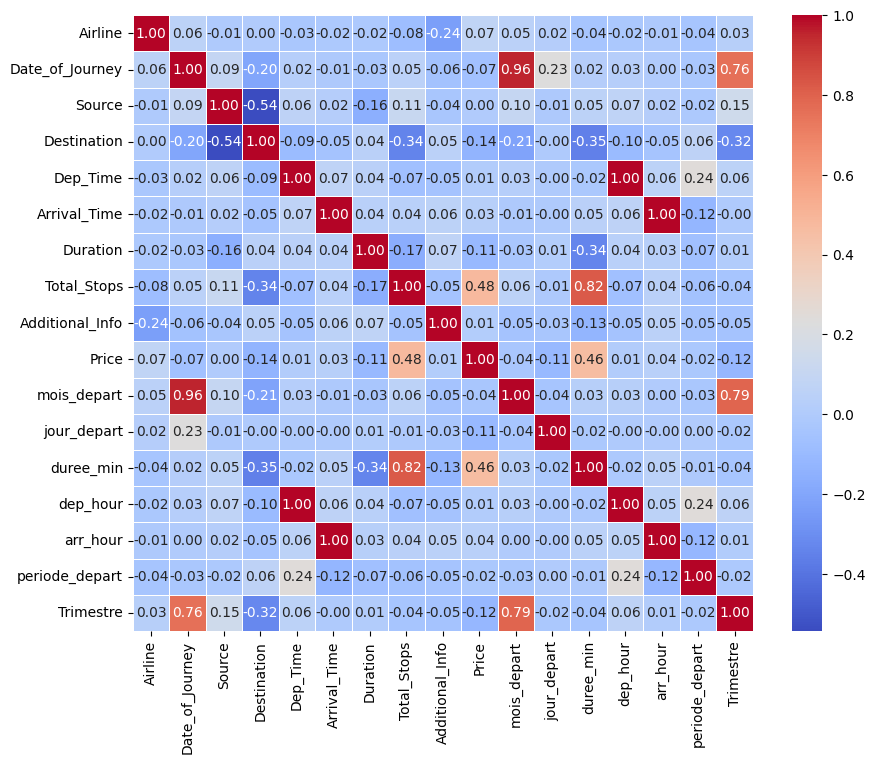

In [291]:
#Matrice de correlation: nécéssaire pour trouver les rélations entre les variables

#--création de la colone Trimestre pour vérifier si le prix du billet d'avion dépend de la période
data['Trimestre'] = ((data['mois_depart'] - 1) // 3) + 1

#encodage des variables catégorielle pour etre sur d'avoir toute les corrélation dans le dataset
from sklearn.preprocessing import LabelEncoder
plt.figure(figsize=(10, 8))
df_encoded = data.copy()

le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

#matrice de correlation en représentation graphique pour avoir une meilleur vue sur les coefficients et les corrélation dans le dataset
corr = df_encoded.corr(method='spearman')

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()

interprétation: de cette matrice de correlation on voit qu'il n'ya que la durée du vol et le nombre de stop qui sont en corrélation linéaire forte avec le prix des billets,tant dis que les autres sont en faible corrélation linéair,
N.B: ceci ne veut pas dire qu'il y'a pas de rélation entre le prix et les autres valeurs, juste que cette rélation n'est pas linéaire

Nous allons maintenant nous pencher sur une analyse visuelle des différents parametres pouvant influencer le prix des billets d'avion 

In [292]:
#vérifier le nombre de vols par trimestre
data_group=data.groupby("Trimestre")["Trimestre"].count()
data_group

Trimestre
1    3412
2    9941
Name: Trimestre, dtype: int64

In [240]:
data_Test.head(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info,15998
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info,16612
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included,25572
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info,25778
4,Air Asia,24/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info,16934


In [293]:
print(data.columns)

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Dep_Time',
       'Arrival_Time', 'Duration', 'Total_Stops', 'Additional_Info', 'Price',
       'mois_depart', 'jour_depart', 'duree_min', 'dep_hour', 'arr_hour',
       'periode_depart', 'Trimestre'],
      dtype='str')


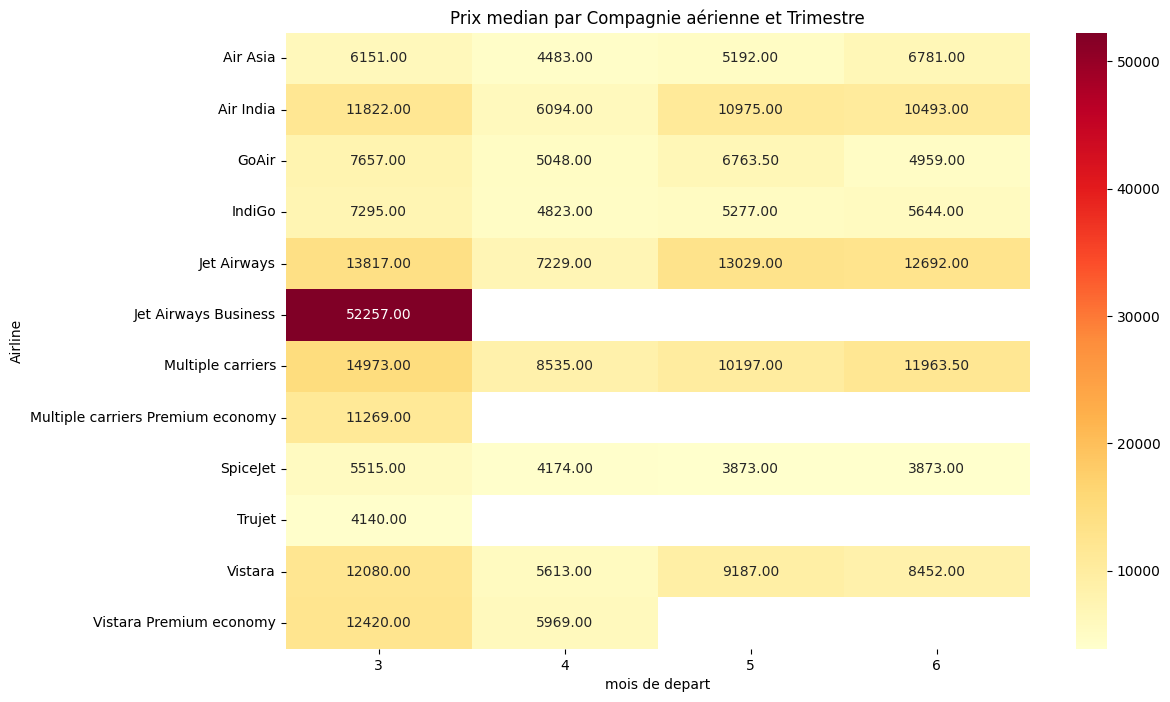

In [300]:
#visuel des prix en fonctions des campagnies et des trimestres

import seaborn as sns
import matplotlib.pyplot as plt


data_1= data.groupby("Trimestre")["Price"].mean()
pivot_table = data.pivot_table(values='Price', index='Airline', columns='mois_depart', aggfunc='median')

plt.figure(figsize=(12,8))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title('Prix median par Compagnie aérienne et Trimestre')
plt.ylabel('Airline')
plt.xlabel('mois de depart')
plt.show()

on voit ici que les prix sont influencés par la compagnie aériennes et par la période de l'année de l'année

C:\Users\jorda\AppData\Local\Temp\ipykernel_41036\217399716.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(y=data2["mois_depart"], x=data2["count"],orient='h',palette='viridis')


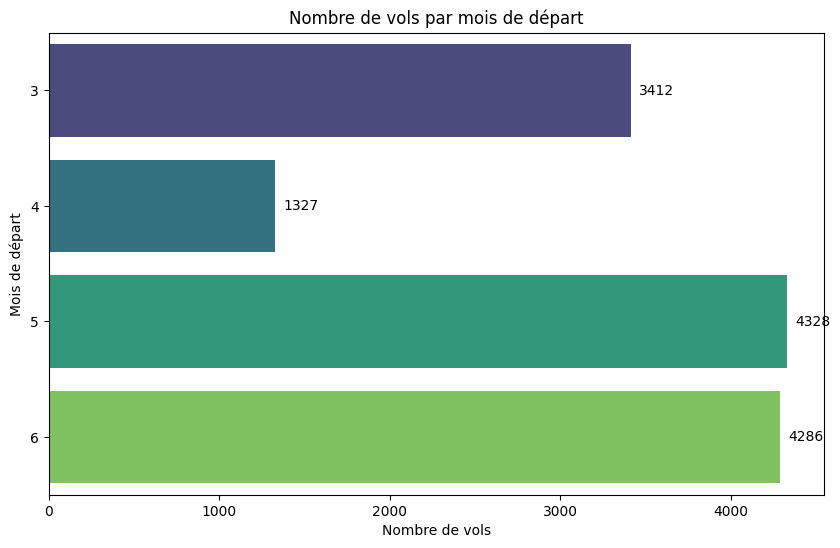

In [295]:
import matplotlib.pyplot as plt
import seaborn as sns
data2 = data.groupby("mois_depart")["mois_depart"].count().reset_index(name='count')
plt.figure(figsize=(10,6))
barplot = sns.barplot(y=data2["mois_depart"], x=data2["count"],orient='h',palette='viridis')

plt.xlabel('Nombre de vols')
plt.ylabel('Mois de départ')
plt.title('Nombre de vols par mois de départ')

# Ajouter les valeurs au bout des barres
for index, value in enumerate(data2["count"]):
    barplot.text(value + 50, index, str(value), va='center')

plt.show()

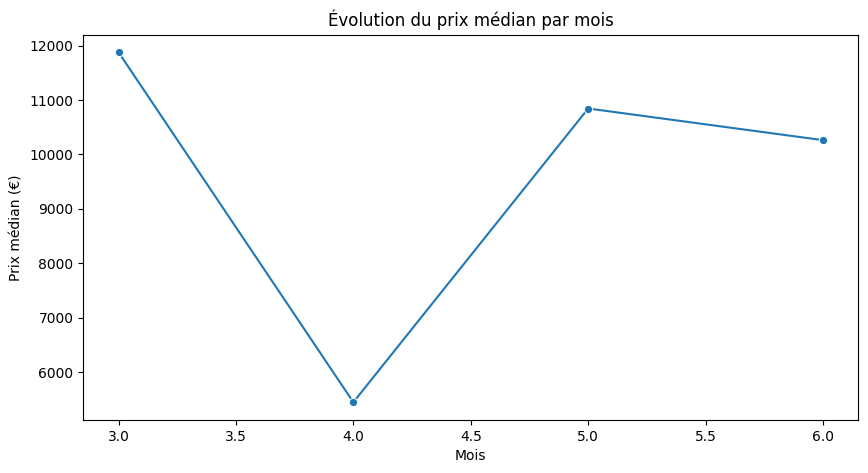

In [296]:
median_price_month = data.groupby('mois_depart')['Price'].median().reset_index()
plt.figure(figsize=(10,5))

sns.lineplot(data=median_price_month, x='mois_depart', y='Price', marker='o')

plt.title('Évolution du prix médian par mois')
plt.xlabel('Mois')
plt.ylabel('Prix médian (€)')
plt.show()

C:\Users\jorda\AppData\Local\Temp\ipykernel_41036\3136769588.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=median_price_by_stops, x='Total_Stops', y='Price', palette='coolwarm')


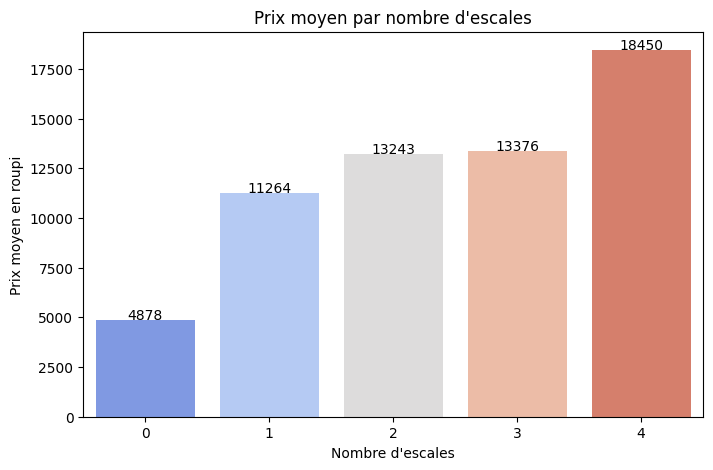

In [297]:
#visualisation du prix par nombre d'escale
plt.figure(figsize=(8,5))
median_price_by_stops = data.groupby('Total_Stops')['Price'].median().reset_index()
ax = sns.barplot(data=median_price_by_stops, x='Total_Stops', y='Price', palette='coolwarm')

# Ajout des valeurs sur le graphes
for i, value in enumerate(median_price_by_stops['Price']):
    ax.text(i, value + 10, f'{value:.0f}', ha='center')

plt.xlabel('Nombre d\'escales')
plt.ylabel('Prix moyen en roupi')
plt.title('Prix moyen par nombre d\'escales')
plt.show()

comme obtenu dans la matrice de correlation, le prix est bien lié au prix et plus il y'a d'escale, plus le prix est élévé

C:\Users\jorda\AppData\Local\Temp\ipykernel_41036\2733699344.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=median_price, x='periode_depart', y='Price', palette='viridis')


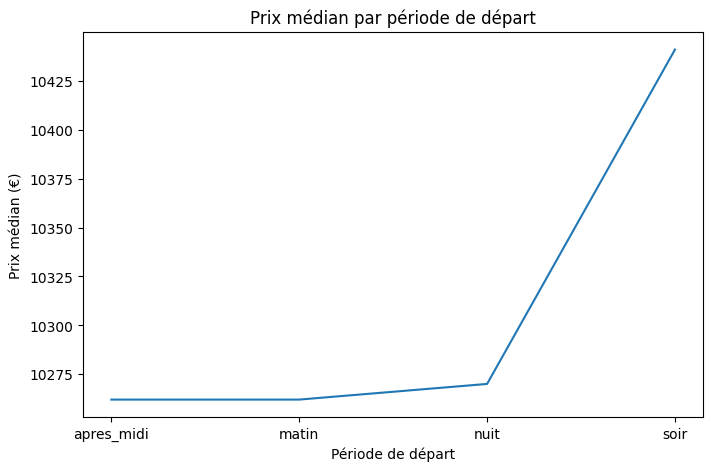

In [298]:
#prix par période de départ
median_price = data.groupby('periode_depart')['Price'].median().reset_index()
median_price
plt.figure(figsize=(8,5))
sns.lineplot(data=median_price, x='periode_depart', y='Price', palette='viridis')

plt.xlabel('Période de départ')
plt.ylabel('Prix médian (€)')
plt.title('Prix médian par période de départ')
plt.show()

ce graphe nous permet de comprendre également que le prix est influencé par la péridoe de départ

Développement des modeles de machine learning 